# ternary model comparison

In [7]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split

import pandas as pd
from collections import Counter
import random
import seaborn as sns

Image_size = 96
Batch = 32
Random_seed = 42

# ported data processing

In [8]:
def focal_loss_sparse(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true, depth=y_pred.shape[-1])
        
        # Cross entropy
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        
        # Focal weight
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        
        return tf.reduce_mean(focal_weight * ce)
    return loss

def apply_blur(img):
    img = tf.expand_dims(img, 0)  
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0) 

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))    
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights_Tri(ds):
    labels = np.concatenate([y.numpy() for _, y in ds])    
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    class_weights = dict(zip(classes, weights))
    print(f"Class weights: {class_weights}")
    return class_weights


def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [Image_size, Image_size])
    
    return image, label

In [9]:
import tensorflow as tf
import numpy as np

# 1. Define your directory paths based on your folder structure
train_dir = 'Ternary_Training'
val_dir   = 'Ternary_Validation'
test_dir  = 'Ternary_Test'

# 2. Load Datasets from Folders
# Note: This automatically handles labels based on subfolder names
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='int', 
    batch_size=Batch,
    image_size=(Image_size, Image_size),
    shuffle=True,
    seed=Random_seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='int',
    batch_size=Batch,
    image_size=(Image_size, Image_size)
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='int',
    batch_size=Batch,
    image_size=(Image_size, Image_size)
)

class_names = test_ds.class_names  # add this line right after image_dataset_from_directory
# image_dataset_from_directory already decodes & resizes images,
# so load_and_preprocess is not needed here.
train_ds = (
    train_ds
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)


class_weights = compute_class_weights_Tri(train_ds)

Found 6154 files belonging to 3 classes.
Found 1086 files belonging to 3 classes.
Found 1810 files belonging to 3 classes.
Class weights: {0: 0.5850922228560563, 1: 1.1264872780523523, 2: 2.4804514308746475}


In [10]:


model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling2D(),
    
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax') 
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss= 'sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight= class_weights,
)



Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6960 - loss: 0.6692 - val_accuracy: 0.2956 - val_loss: 1.3550
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7746 - loss: 0.4799 - val_accuracy: 0.3315 - val_loss: 1.1463
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8412 - loss: 0.4168 - val_accuracy: 0.4457 - val_loss: 0.7948
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8611 - loss: 0.3782 - val_accuracy: 0.5350 - val_loss: 0.7955
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8646 - loss: 0.3579 - val_accuracy: 0.7873 - val_loss: 0.5060
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8759 - loss: 0.3335 - val_accuracy: 0.7413 - val_loss: 0.5857
Epoch 7/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8789 - loss: 0.3311 - val_accuracy: 0.9153 - val_loss: 0.2530
Epoch 8/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8838 - loss: 0.3108 - val_accu

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

true_labels = []
y_pred_prob = []

print("Running model on test data...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    true_labels.extend(labels.numpy())
    y_pred_prob.extend(preds)

true_labels = np.array(true_labels)
y_pred_prob = np.array(y_pred_prob)

FIRE_THRESHOLD = 0.5

LAKE_THRESHOLD = 0.5

final_preds = []
# Replace your threshold loop with this:
final_preds = np.argmax(y_pred_prob, axis=1)
        
final_preds = np.array(final_preds)

print("\nAdjusted Classification Report:")
# Assuming your classes are 0: Fire, 1: Lake, 2: No_Fire based on your folder structure
print(classification_report(true_labels, final_preds, target_names=['Fire', 'Lake', 'No_Fire']))

print("\nAdjusted Confusion Matrix:")
print(confusion_matrix(true_labels, final_preds))


Running model on test data...

Adjusted Classification Report:
              precision    recall  f1-score   support

        Fire       0.98      0.94      0.96      1032
        Lake       1.00      1.00      1.00       535
     No_Fire       0.78      0.92      0.84       243

    accuracy                           0.95      1810
   macro avg       0.92      0.95      0.93      1810
weighted avg       0.96      0.95      0.96      1810


Adjusted Confusion Matrix:
[[970   0  62]
 [  0 535   0]
 [ 20   0 223]]


# og model to big. must add callbacks to make it better and shorten it. do with coparsion also makes false predictions often due to smoke or smt

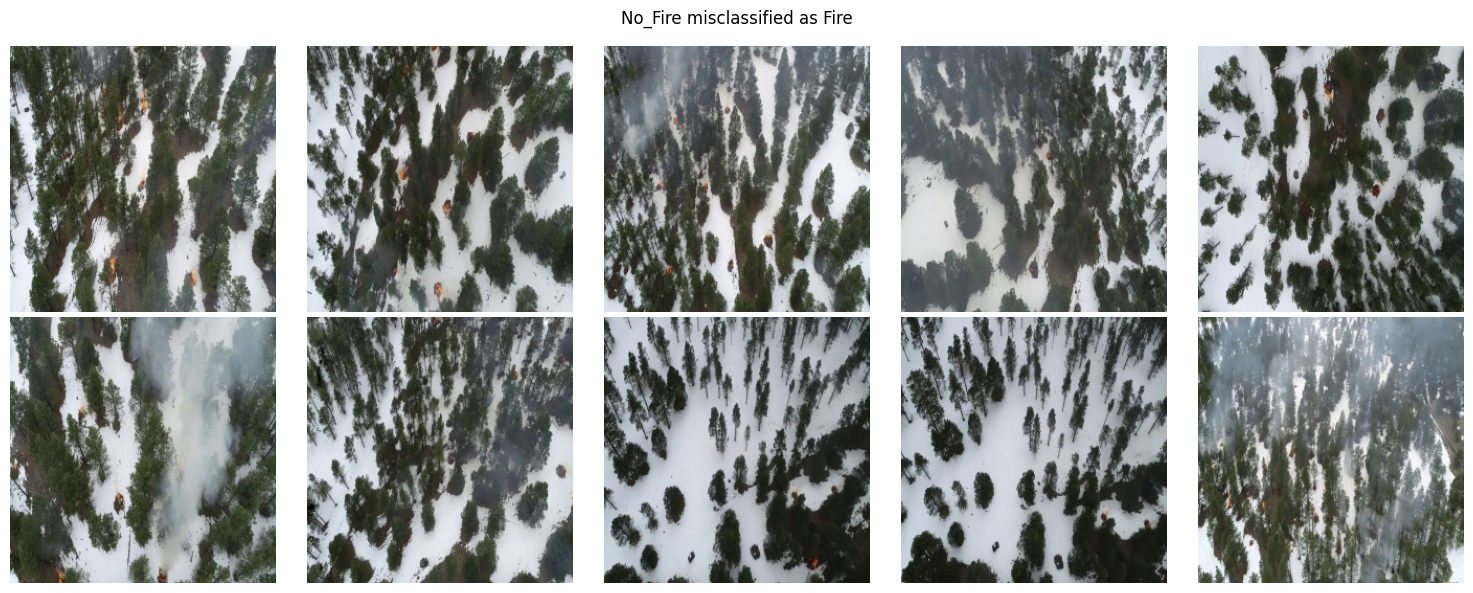

In [12]:
true_labels_arr = np.array(true_labels)
final_preds_arr = np.array(final_preds)

# Build class index mapping from the dataset
class_to_idx = {name: i for i, name in enumerate(class_names)}
# Collect file paths from the test directory
import glob
test_paths = []
for label_name in class_names:  
    test_paths.extend(sorted(glob.glob(os.path.join(test_dir, label_name, '*'))))

# Sort to match the order image_dataset_from_directory uses
test_paths = sorted(test_paths)

# Find No_Fire images predicted as Fire
no_fire_idx = class_to_idx['No_Fire']
fire_idx = class_to_idx['Fire']

misclassified = [
    test_paths[i] for i in range(len(test_paths))
    if true_labels_arr[i] == no_fire_idx and final_preds_arr[i] == fire_idx
]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path in zip(axes.flat, misclassified[:10]):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('No_Fire misclassified as Fire')
plt.tight_layout()
plt.show()


# vary model sizs 

In [13]:
def build_fire_model_scaled(model_size='medium', loss_fn=None):
    scales = {
        'very_small': (2, 8,  8),
        'small':      (3, 8,  16),
        'medium':     (4, 8,  32),
        'large':      (5, 8,  64),
    }
    num_blocks, base_filters, dense_dim = scales[model_size]
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=['accuracy'] # Removed precision/recall here to prevent Shape/Key Errors
    )
    return model

def run_experiment(size, loss_func, weights, callbacks):
    print(f"\n--- TESTING {size.upper()} ---")
    model = build_fire_model_scaled(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    # Plotting only the metrics that exist
    metrics = ['loss', 'accuracy'] 
    plt.figure(figsize=(12, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history


--- TESTING VERY_SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5843 - loss: 1.0855 - val_accuracy: 0.7753 - val_loss: 1.0231 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7177 - loss: 0.9660 - val_accuracy: 0.8656 - val_loss: 0.6667 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7255 - loss: 0.8000 - val_accuracy: 0.8646 - val_loss: 0.5811 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7493 - loss: 0.7483 - val_accuracy: 0.8600 - val_loss: 0.5465 - learning_rate: 1.0000e-04
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7424 - loss: 0.7231 - val_accuracy: 0.8637 - val_loss: 0.5325 - learning_rate: 1.0000e-04
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7507 - loss: 0.7045 - val_accuracy: 0.8407 - val_loss: 0.5507 - learning_rate: 1.0000e-04
Epoch 7/30
193/193 ━━━━━━━━━━━

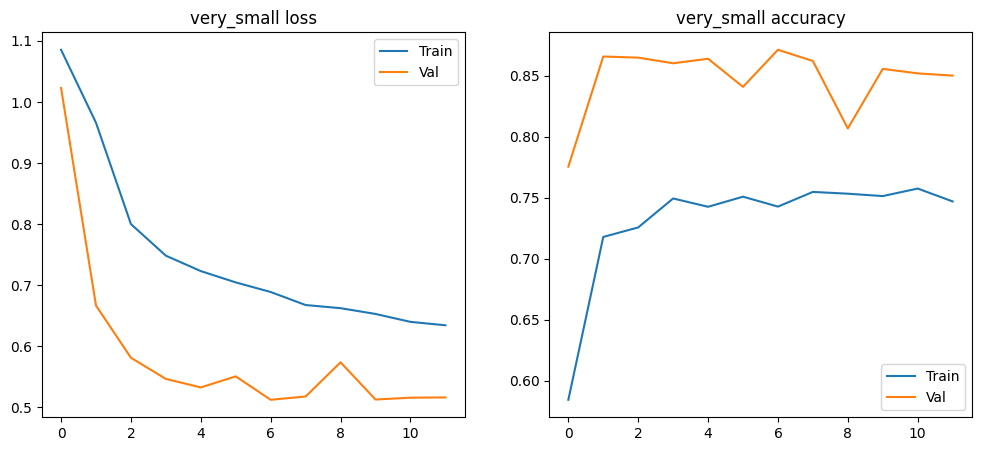


--- TESTING SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5505 - loss: 1.0461 - val_accuracy: 0.5820 - val_loss: 0.9408 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6516 - loss: 0.7887 - val_accuracy: 0.5258 - val_loss: 0.6077 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6295 - loss: 0.6200 - val_accuracy: 0.4899 - val_loss: 0.5673 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6843 - loss: 0.5894 - val_accuracy: 0.5092 - val_loss: 0.5602 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6878 - loss: 0.5803 - val_accuracy: 0.6234 - val_loss: 0.5609 - learning_rate: 5.0000e-05


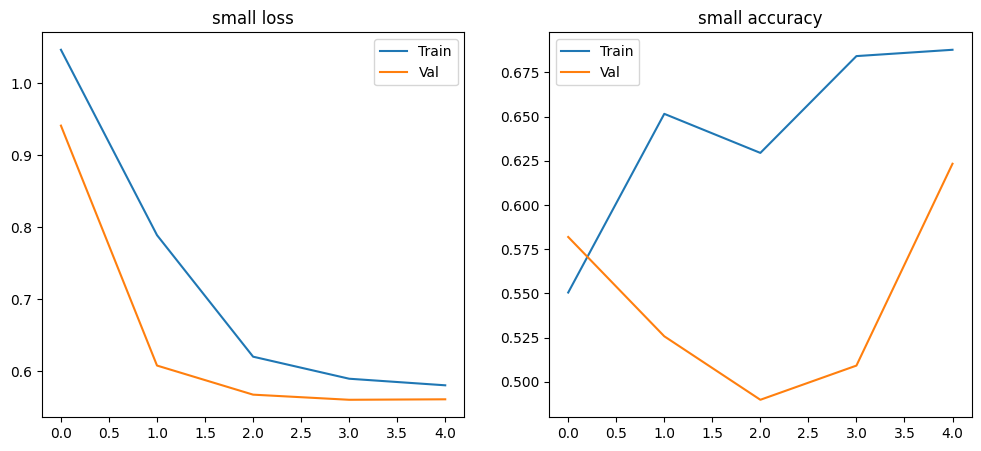


--- TESTING MEDIUM ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5037 - loss: 1.0144 - val_accuracy: 0.4355 - val_loss: 0.7334 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5952 - loss: 0.6411 - val_accuracy: 0.5387 - val_loss: 0.6561 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6596 - loss: 0.5689 - val_accuracy: 0.4006 - val_loss: 0.6862 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6488 - loss: 0.5315 - val_accuracy: 0.5691 - val_loss: 0.6961 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6708 - loss: 0.5252 - val_accuracy: 0.5709 - val_loss: 0.6464 - learning_rate: 5.0000e-05


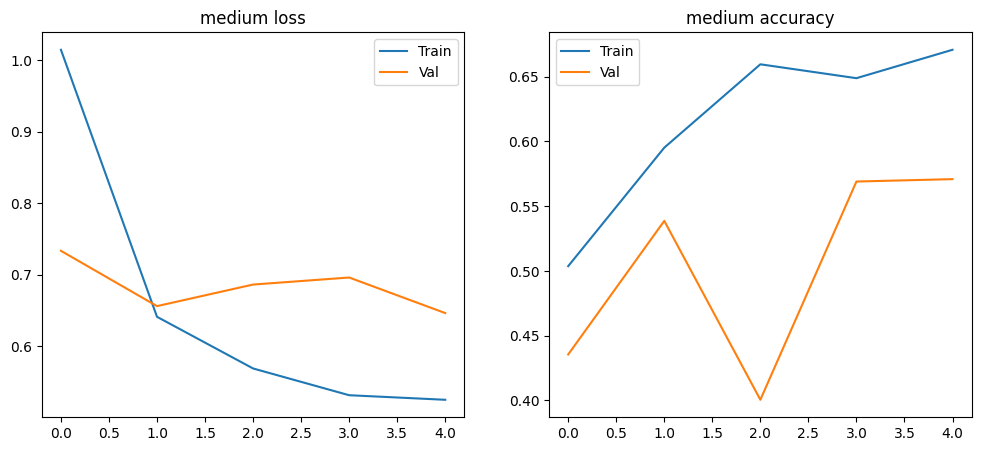

In [14]:
# Configure your variables
focal_loss = 'sparse_categorical_crossentropy'
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# Run the test
all_results = {}
for model_size in ['very_small', 'small', 'medium']:
    all_results[model_size] = run_experiment(model_size, focal_loss, class_weights, my_callbacks)

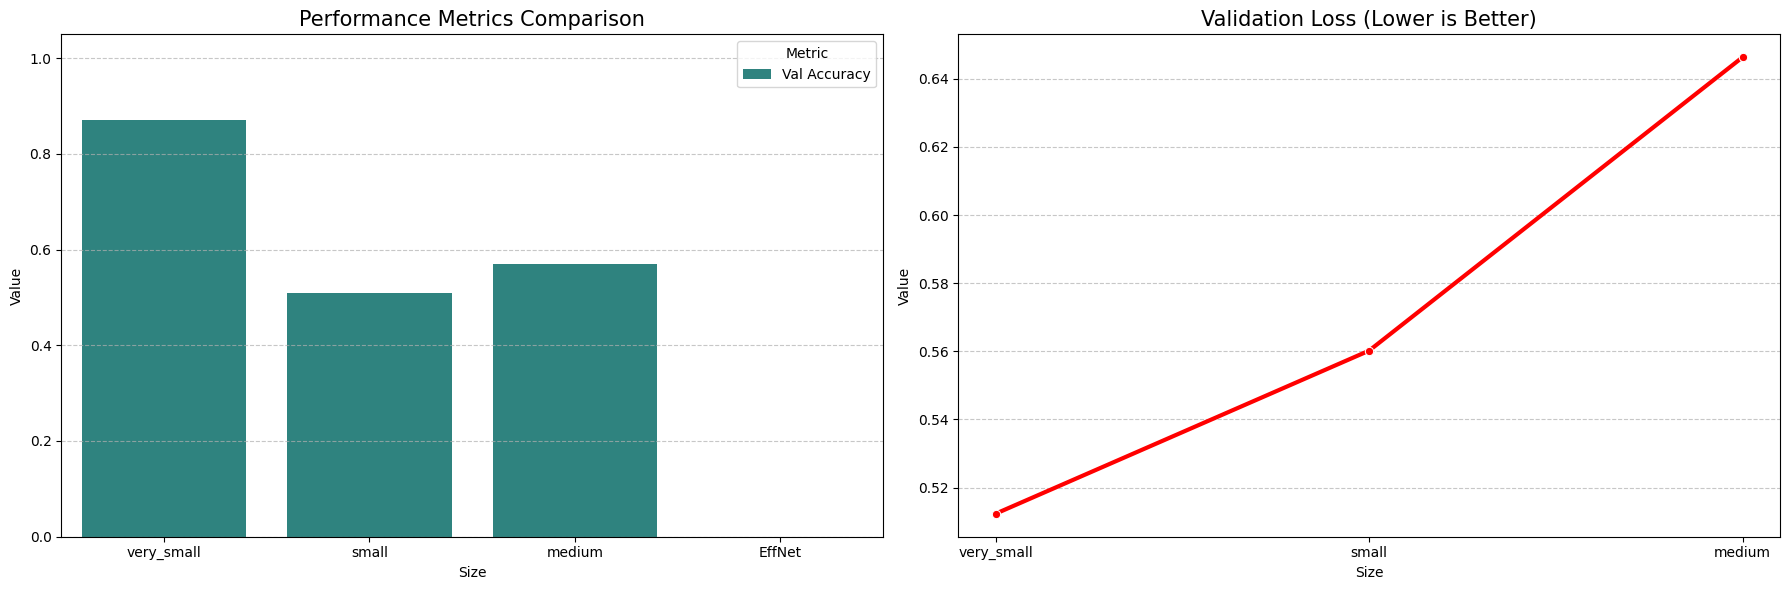

In [15]:
def plot_model_comparison(results_dict):
    data = []
    for size, result in results_dict.items():
        # 1. Handle the tuple (model, history)
        # In your run_experiment, index 0 is model, index 1 is history
        if isinstance(result, tuple):
            history_obj = result[1] 
        else:
            history_obj = result
        
        # 2. Extract the actual dictionary of metrics
        h = history_obj.history 
        
        # 3. Use 'h' (the dictionary) to find the best epoch
        best_epoch = np.argmin(h['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': h['val_accuracy'][best_epoch],
            'Val Loss': h['val_loss'][best_epoch],
        }
        
        # 4. Check for optional metrics using the dict 'h'
        if 'val_precision' in h:
            row['Val Precision'] = h['val_precision'][best_epoch]
            row['Val Recall'] = h['val_recall'][best_epoch]
            
        data.append(row)

    # --- Rest of your plotting code stays the same ---
    df = pd.DataFrame(data)
    order = ['very_small', 'small', 'medium','EffNet']
    df['Size'] = pd.Categorical(df['Size'], categories=order, ordered=True)
    df = df.sort_values('Size')

    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='viridis')
    ax1.set_title('Performance Metrics Comparison', fontsize=15)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='red', linewidth=3)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
# To run it:
plot_model_comparison(all_results)

# categorical vs focal loss

--- Starting tests for Loss: Sparse Categorical ---
Training very_small model...

--- TESTING VERY_SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2215 - loss: 1.0935 - val_accuracy: 0.1344 - val_loss: 1.0966 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2517 - loss: 1.0319 - val_accuracy: 0.2256 - val_loss: 0.9115 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5666 - loss: 0.8795 - val_accuracy: 0.4558 - val_loss: 0.6994 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6446 - loss: 0.7477 - val_accuracy: 0.5451 - val_loss: 0.6142 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6224 - loss: 0.6998 - val_accuracy: 0.4963 - val_loss: 0.5862 - learning_rate: 5.0000e-05


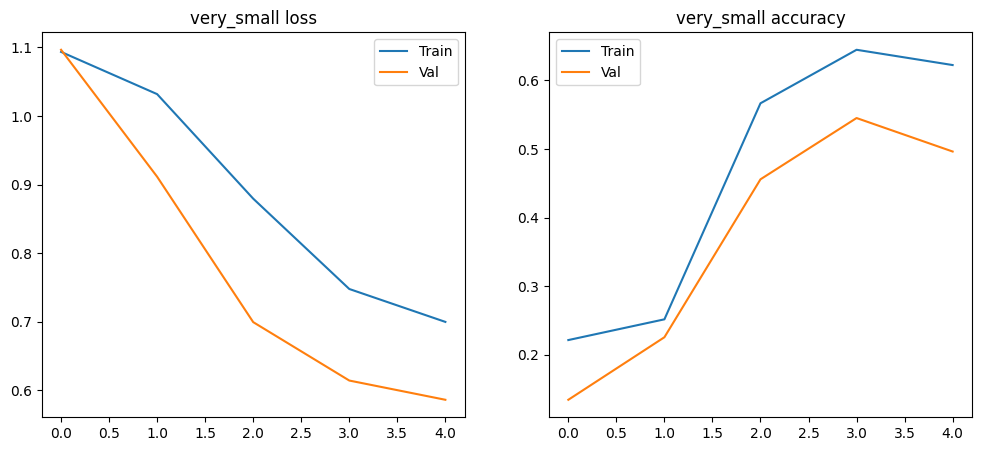

Training small model...

--- TESTING SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4898 - loss: 1.0838 - val_accuracy: 0.6860 - val_loss: 1.0477 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6721 - loss: 0.8830 - val_accuracy: 0.8297 - val_loss: 0.5962 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7332 - loss: 0.6588 - val_accuracy: 0.7928 - val_loss: 0.5861 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7493 - loss: 0.6068 - val_accuracy: 0.8140 - val_loss: 0.5642 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7356 - loss: 0.5880 - val_accuracy: 0.4890 - val_loss: 0.5566 - learning_rate: 5.0000e-05


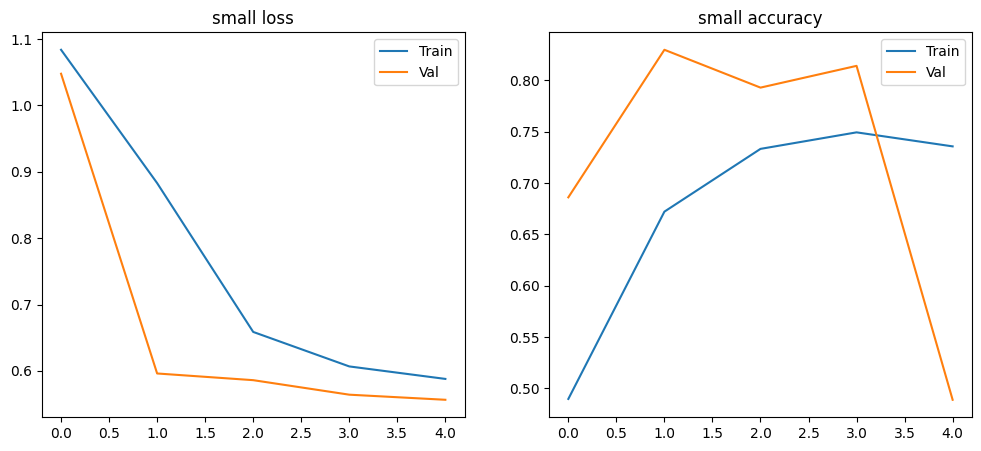

Training medium model...

--- TESTING MEDIUM ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5135 - loss: 0.9775 - val_accuracy: 0.4227 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6110 - loss: 0.5722 - val_accuracy: 0.4208 - val_loss: 0.5693 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6248 - loss: 0.5507 - val_accuracy: 0.4208 - val_loss: 0.5700 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6498 - loss: 0.5046 - val_accuracy: 0.7689 - val_loss: 0.5127 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6402 - loss: 0.5125 - val_accuracy: 0.7449 - val_loss: 0.5403 - learning_rate: 5.0000e-05


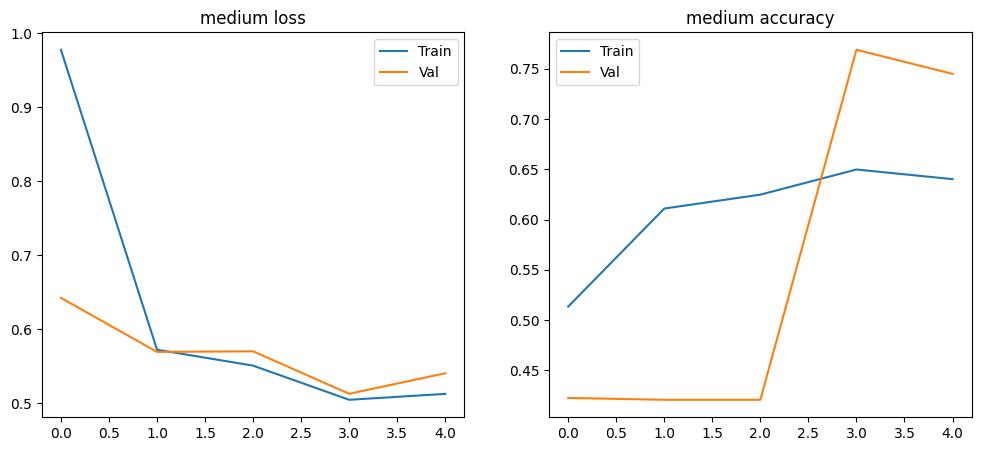

Training large model...

--- TESTING LARGE ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5964 - loss: 0.8291 - val_accuracy: 0.3923 - val_loss: 0.8271 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6264 - loss: 0.5652 - val_accuracy: 0.3969 - val_loss: 0.7318 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6206 - loss: 0.5395 - val_accuracy: 0.6832 - val_loss: 0.7727 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6396 - loss: 0.5217 - val_accuracy: 0.3950 - val_loss: 1.0039 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6497 - loss: 0.5244 - val_accuracy: 0.5912 - val_loss: 0.7327 - learning_rate: 5.0000e-05


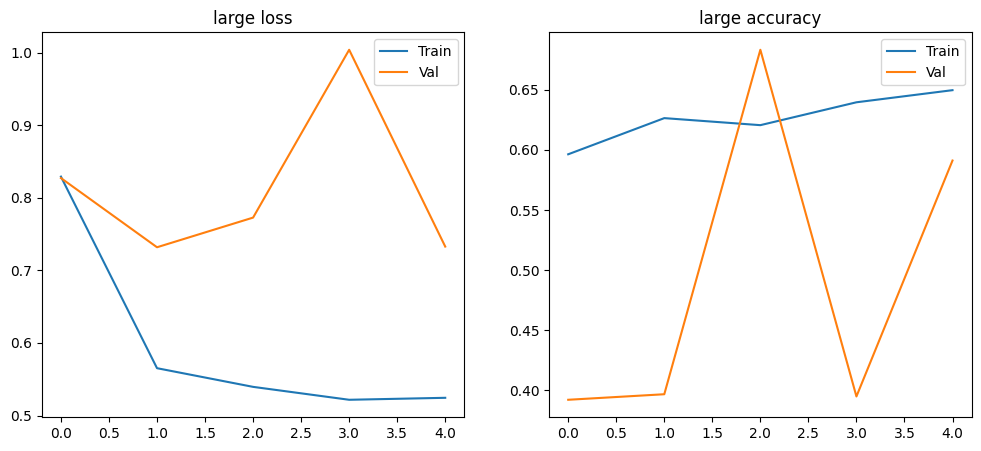

--- Starting tests for Loss: Focal Sparse ---
Training very_small model...

--- TESTING VERY_SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5552 - loss: 0.1051 - val_accuracy: 0.5700 - val_loss: 0.0997 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5744 - loss: 0.1004 - val_accuracy: 0.5773 - val_loss: 0.0921 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7502 - loss: 0.0825 - val_accuracy: 0.8656 - val_loss: 0.0624 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8253 - loss: 0.0689 - val_accuracy: 0.8646 - val_loss: 0.0541 - learning_rate: 1.0000e-04
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8362 - loss: 0.0644 - val_accuracy: 0.8656 - val_loss: 0.0523 - learning_rate: 1.0000e-04
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8354 - loss: 0.0603 - val_accuracy: 0.8656 - 

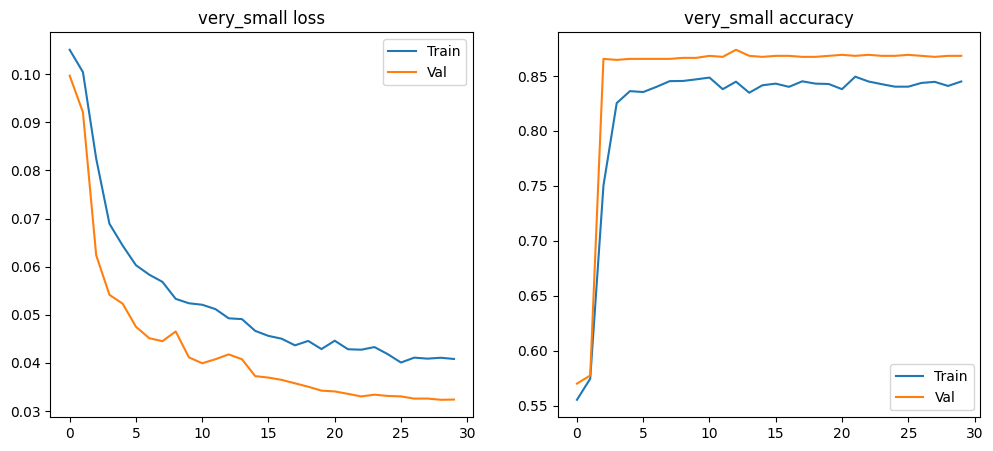

Training small model...

--- TESTING SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5658 - loss: 0.1013 - val_accuracy: 0.5727 - val_loss: 0.1004 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7065 - loss: 0.0763 - val_accuracy: 0.8600 - val_loss: 0.0566 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7915 - loss: 0.0510 - val_accuracy: 0.8453 - val_loss: 0.0417 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8071 - loss: 0.0415 - val_accuracy: 0.8149 - val_loss: 0.0446 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8182 - loss: 0.0387 - val_accuracy: 0.8361 - val_loss: 0.0396 - learning_rate: 5.0000e-05


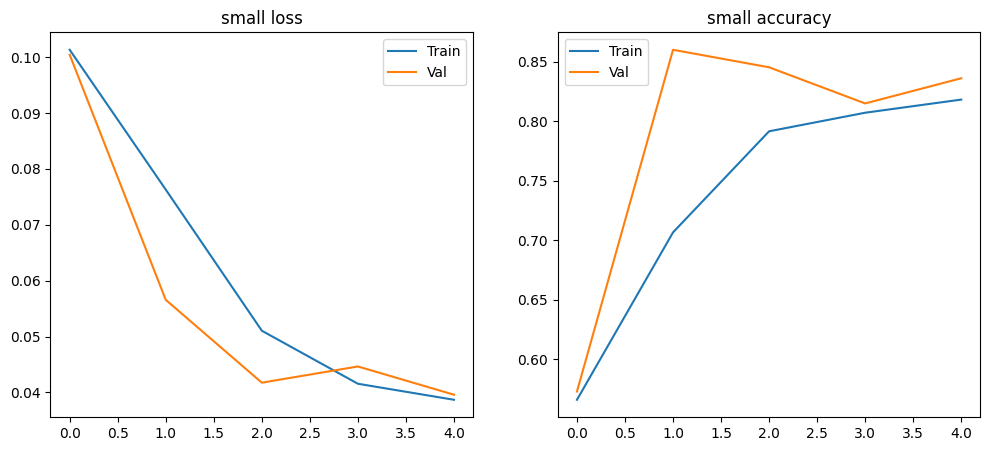

Training medium model...

--- TESTING MEDIUM ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5682 - loss: 0.1025 - val_accuracy: 0.8214 - val_loss: 0.1090 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7501 - loss: 0.0682 - val_accuracy: 0.2956 - val_loss: 0.2405 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8161 - loss: 0.0411 - val_accuracy: 0.2956 - val_loss: 0.3588 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8354 - loss: 0.0350 - val_accuracy: 0.4171 - val_loss: 0.1816 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8339 - loss: 0.0358 - val_accuracy: 0.4024 - val_loss: 0.1958 - learning_rate: 5.0000e-05


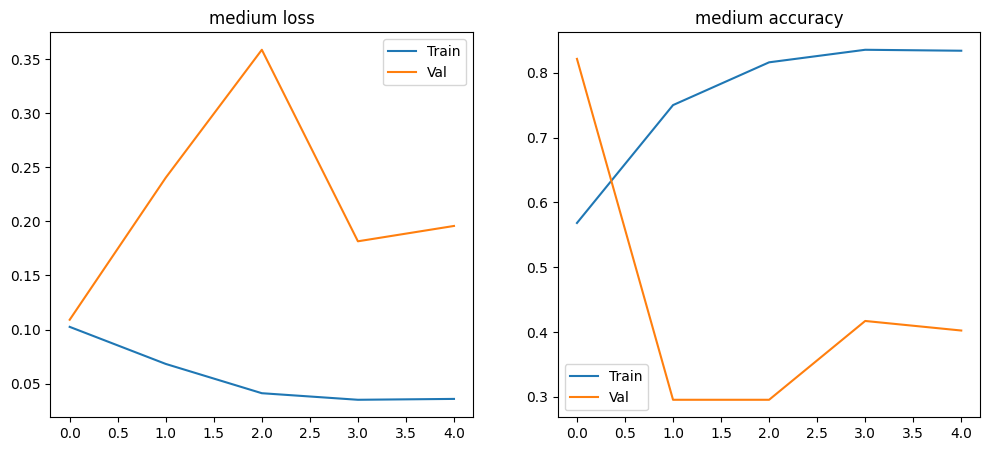

Training large model...

--- TESTING LARGE ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5873 - loss: 0.0993 - val_accuracy: 0.7081 - val_loss: 0.1045 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8180 - loss: 0.0449 - val_accuracy: 0.5994 - val_loss: 0.2026 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8507 - loss: 0.0322 - val_accuracy: 0.7109 - val_loss: 0.0961 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8534 - loss: 0.0296 - val_accuracy: 0.6878 - val_loss: 0.1276 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8586 - loss: 0.0294 - val_accuracy: 0.6869 - val_loss: 0.1275 - learning_rate: 5.0000e-05


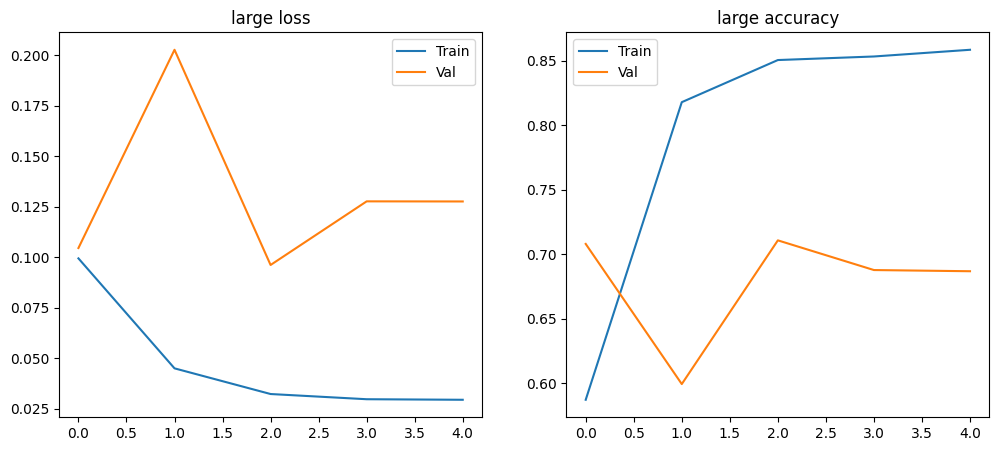

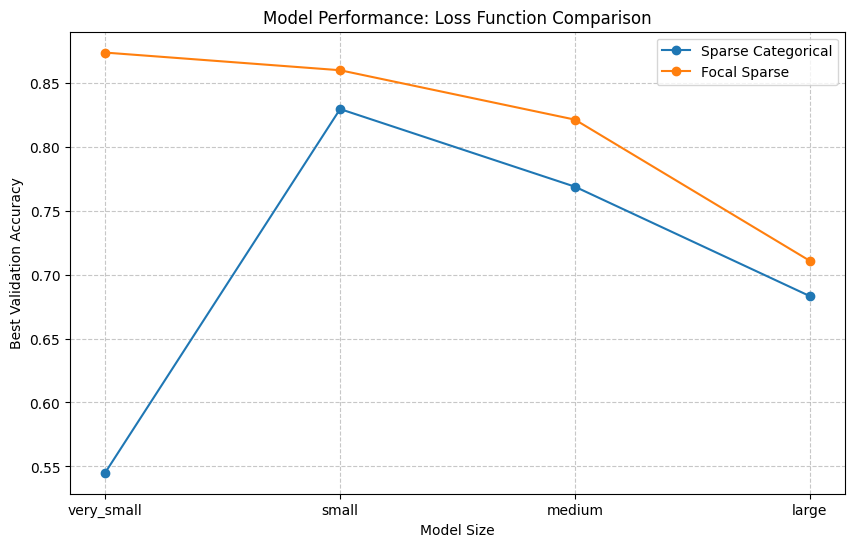


Final Comparison Table (Val Accuracy):
            Sparse Categorical  Focal Sparse
very_small            0.545120      0.873849
small                 0.829650      0.860037
medium                0.768877      0.821363
large                 0.683241      0.710866


AttributeError: 'Series' object has no attribute 'history'

In [17]:
losses_to_test = {
    'Sparse Categorical': 'sparse_categorical_crossentropy',
    'Focal Sparse': focal_loss_sparse(gamma=2.0, alpha=0.25)
}
model_sizes = ['very_small', 'small', 'medium', 'large']
all_results = {}

# 2. Run the nested experiment
for loss_name, loss_fn in losses_to_test.items():
    print(f"--- Starting tests for Loss: {loss_name} ---")
    all_results[loss_name] = {}
    
    for model_size in model_sizes:
        print(f"Training {model_size} model...")
        # run_experiment should return the final validation accuracy or the history object
        result = run_experiment(model_size, loss_fn, class_weights, my_callbacks)
        
        # Extract the best validation accuracy (assuming result is a history object)
        # If your function returns a float, just use: all_results[loss_name][model_size] = result
        model_obj, hist_obj = result
        all_results[loss_name][model_size] = max(hist_obj.history['val_accuracy'])

# 3. Plotting the Comparison
plt.figure(figsize=(10, 6))

for loss_name, scores in all_results.items():
    # scores is a dict like {'very_small': 0.85, 'small': 0.88, ...}
    plt.plot(list(scores.keys()), list(scores.values()), marker='o', label=loss_name)

plt.title('Model Performance: Loss Function Comparison')
plt.xlabel('Model Size')
plt.ylabel('Best Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Optional: Print results as a Table
df_results = pd.DataFrame(all_results)
print("\nFinal Comparison Table (Val Accuracy):")
print(df_results)
plot_model_comparison(df_results)

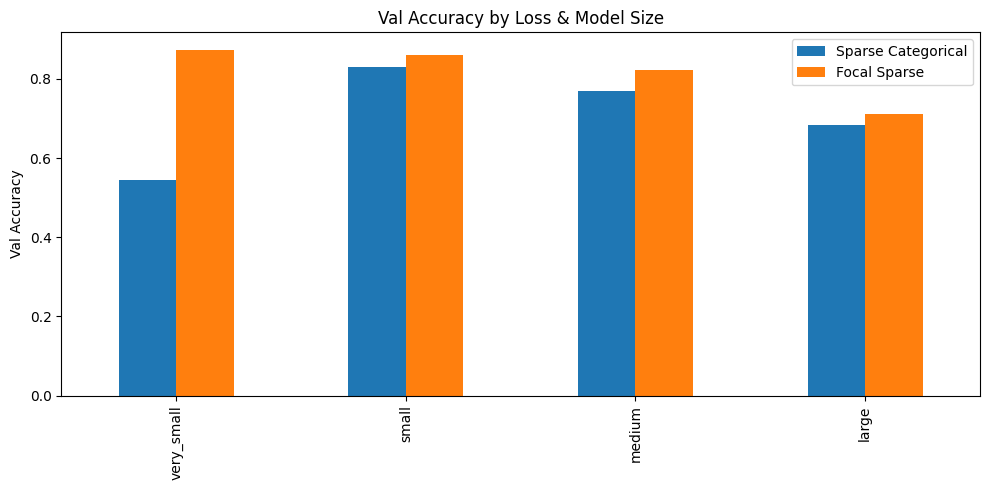

In [19]:
df_results.plot(kind='bar', figsize=(10, 5), title='Val Accuracy by Loss & Model Size')
plt.ylabel('Val Accuracy')
plt.tight_layout()
plt.show()

# closer comparison look


--- TESTING VERY_SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5595 - loss: 1.0970 - val_accuracy: 0.5700 - val_loss: 1.0762 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6207 - loss: 1.0743 - val_accuracy: 0.8066 - val_loss: 0.9716 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7645 - loss: 0.9626 - val_accuracy: 0.7873 - val_loss: 0.7767 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6695 - loss: 0.7869 - val_accuracy: 0.6584 - val_loss: 0.7082 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6532 - loss: 0.7168 - val_accuracy: 0.7901 - val_loss: 0.6378 - learning_rate: 5.0000e-05


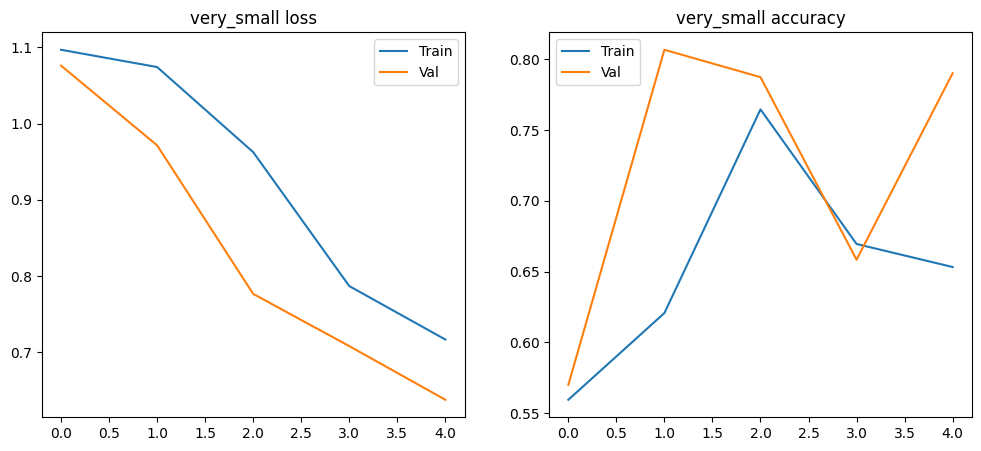


--- TESTING SMALL ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4396 - loss: 1.0375 - val_accuracy: 0.3840 - val_loss: 0.9102 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6407 - loss: 0.7597 - val_accuracy: 0.4245 - val_loss: 0.6459 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6518 - loss: 0.6384 - val_accuracy: 0.4208 - val_loss: 0.6239 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6651 - loss: 0.6094 - val_accuracy: 0.4190 - val_loss: 0.6038 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6974 - loss: 0.5919 - val_accuracy: 0.4337 - val_loss: 0.6183 - learning_rate: 5.0000e-05


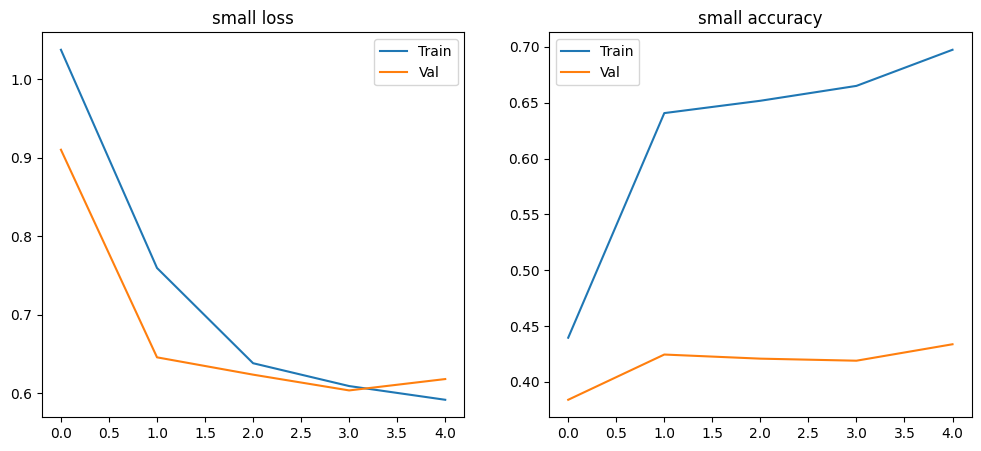


--- TESTING MEDIUM ---
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4452 - loss: 0.9548 - val_accuracy: 0.4190 - val_loss: 0.7693 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6076 - loss: 0.5589 - val_accuracy: 0.4190 - val_loss: 0.6230 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6108 - loss: 0.5178 - val_accuracy: 0.4180 - val_loss: 0.6266 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6485 - loss: 0.5088 - val_accuracy: 0.5902 - val_loss: 0.6658 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6388 - loss: 0.5057 - val_accuracy: 0.5958 - val_loss: 0.6442 - learning_rate: 5.0000e-05


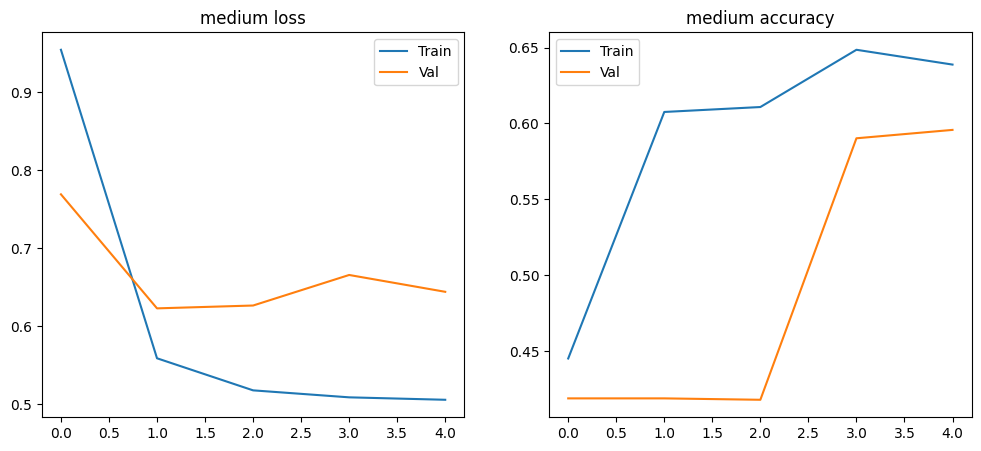

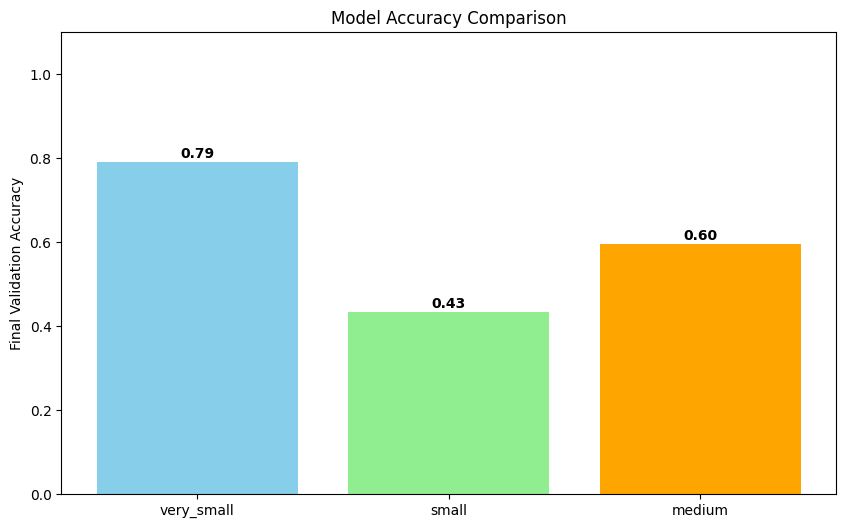

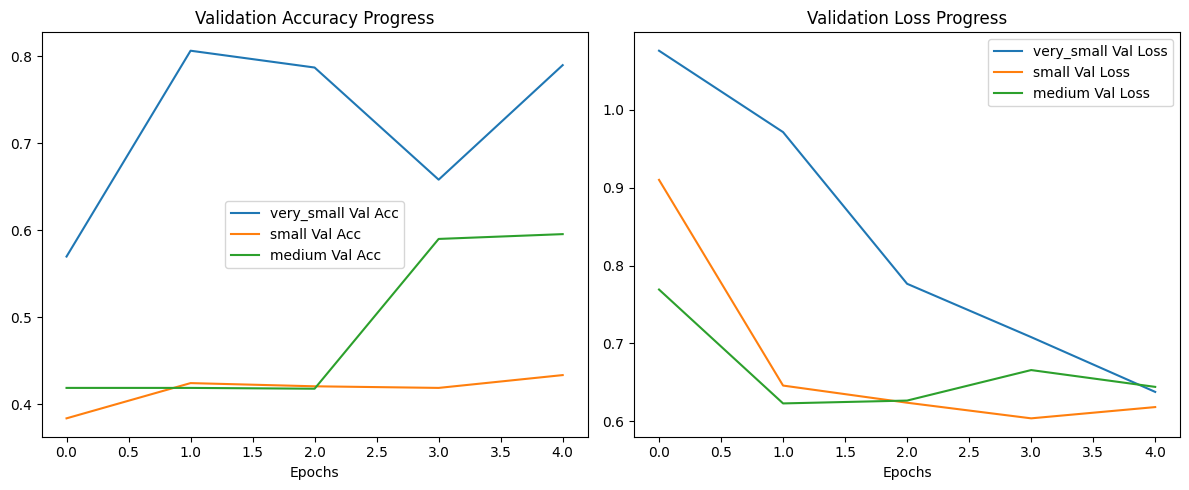

In [21]:
def plot_model_analysis(all_results):
    model_names = list(all_results.keys())  # Get all trained models
    num_models = len(model_names)
    
    # 1. Bar Chart for Final Accuracy
    plt.figure(figsize=(10, 6))
    final_accs = [all_results[m][1].history['val_accuracy'][-1] for m in model_names]
    
    plt.bar(model_names, final_accs, color=['skyblue', 'lightgreen', 'orange'][:num_models])
    plt.ylabel('Final Validation Accuracy')
    plt.title('Model Accuracy Comparison')
    for i, v in enumerate(final_accs):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.show()

    # 2. Training Progress Lines
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    for name in model_names:
        history = all_results[name][1]
        plt.plot(history.history['val_accuracy'], label=f'{name} Val Acc')
    plt.title('Validation Accuracy Progress')
    plt.xlabel('Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    for name in model_names:
        history = all_results[name][1]
        plt.plot(history.history['val_loss'], label=f'{name} Val Loss')
    plt.title('Validation Loss Progress')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
all_results = {}
for model_size in ['very_small', 'small', 'medium']:
    all_results[model_size] = run_experiment(model_size, focal_loss, class_weights, my_callbacks)

plot_model_analysis(all_results)

# useing efficient netV2


--- TESTING EFFICIENTNETV2B0 (TERNARY) ---

Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 52s 169ms/step - accuracy: 0.8243 - loss: 0.4779 - val_accuracy: 0.8794 - val_loss: 0.3186 - learning_rate: 1.0000e-04
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.9475 - loss: 0.1510 - val_accuracy: 0.9659 - val_loss: 0.1091 - learning_rate: 1.0000e-04
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.9672 - loss: 0.0894 - val_accuracy: 0.9843 - val_loss: 0.0720 - learning_rate: 1.0000e-04
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.9771 - loss: 0.0651 - val_accuracy: 0.9512 - val_loss: 0.1475 - learning_rate: 5.0000e-05
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 30s 156ms/step - accuracy: 0.9789 - loss: 0.0571 - val_accuracy: 0.9208 - val_loss: 0.2124 - learning_rate: 5.0000e-05


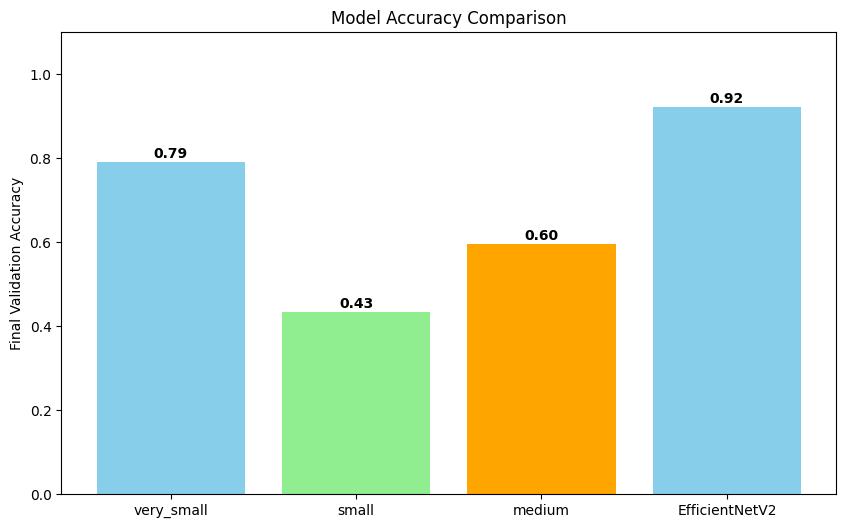

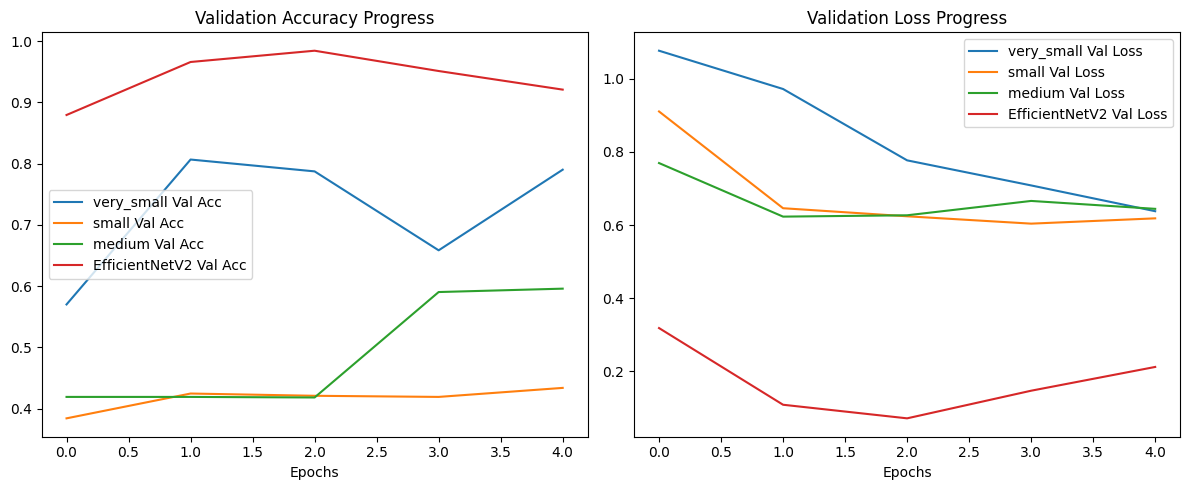

In [22]:
def build_effnet_ternary_model(loss_fn=None):
    inputs = keras.layers.Input(shape=(96, 96, 3))
    
    # Scale [0, 1] back up to [0, 255] for EfficientNetV2's internal preprocessing
    x = keras.layers.Lambda(lambda tensor: tensor * 255.0)(inputs)

    # Load pre-trained EfficientNetV2B0
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(96, 96, 3)
    )
    
    # Fine-tune the pre-trained weights
    base_model.trainable = True

    # Rebuild the top layers for 3 classes
    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(3, activation='softmax')(x)

    model = keras.models.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

# --- Run the EfficientNetV2 Experiment ---
print("\n--- TESTING EFFICIENTNETV2B0 (TERNARY) ---")
effnet_ter_model = build_effnet_ternary_model(focal_loss)

history_effnet_ter = effnet_ter_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=my_callbacks,
    verbose=1
)

# Append to your existing results dictionary
all_results['EfficientNetV2'] = (effnet_ter_model, history_effnet_ter)

# Now, re-run your plot function to see the comparison!
plot_model_analysis(all_results)

# compare again seperable and conv 

In [24]:
import keras_tuner as kt
# 2. Define the model builder function based on your 'small' scale (8 filters, 16 dense)
def model_builder(hp):
    # Fixed 'small' parameters from your notebook
    num_blocks = 8 
    base_filters = 16 
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(Image_size, Image_size, 3)))

    # Replicating your Conv2D block loop
    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        
        # Tune dropout per block layer
        hp_dropout = hp.Float(f'dropout_block_{i}', min_value=0.2, max_value=0.4, step=0.1)
        model.add(keras.layers.Dropout(hp_dropout))
        
        # Limit depth to prevent resource exhaustion during tuning
        if i >= 2: break 

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    
    # Tune the dense dimension (your baseline was 16)
    hp_dense_units = hp.Int('dense_dim', min_value=16, max_value=64, step=16)
    model.add(keras.layers.Dense(hp_dense_units, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    
    # 3 classes for ternary output
    model.add(keras.layers.Dense(3, activation='softmax'))

    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy', # or focal_loss_sparse if you prefer
        metrics=['accuracy']
    )
    return model

# 3. Instantiate Hyperband
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='hyperband_ternary_dir',
    project_name='fire_lake_tuning'
)

# 4. Run the search using your existing datasets and weights
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[stop_early],
    class_weight=class_weights 
)

# 5. Retrieve best hyperparameters and build final model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Dense Units: {best_hps.get('dense_dim')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

final_tuned_model = tuner.hypermodel.build(best_hps)
history = final_tuned_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=30, 
    class_weight=class_weights,
    callbacks=my_callbacks
)

Trial 30 Complete [00h 01m 51s]
val_accuracy: 0.8839778900146484

Best val_accuracy So Far: 0.9447513818740845
Total elapsed time: 00h 21m 22s
Best Dense Units: 16
Best Learning Rate: 0.001
Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6302 - loss: 0.7427 - val_accuracy: 0.4263 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6315 - loss: 0.5777 - val_accuracy: 0.8435 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.6562 - loss: 0.5423 - val_accuracy: 0.8389 - val_loss: 0.5375 - learning_rate: 0.0010
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.6449 - loss: 0.5048 - val_accuracy: 0.4420 - val_loss: 0.5059 - learning_rate: 5.0000e-04
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6880 - loss: 0.4668 - val_accuracy: 0.8315 - val_loss: 0.4383 - learning_rate: 5.0000e-04


Trial 30 Complete [00h 01m 51s]
val_accuracy: 0.8839778900146484

Best val_accuracy So Far: 0.9447513818740845
Total elapsed time: 00h 21m 22s
Best Dense Units: 16
Best Learning Rate: 0.001
